# **CS 559-WS1: Machine Learning: Fundamentals and Applications**
# **Homework 4**

**Name: Ankit Dhandharia**

**CWID: 20033031**

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import warnings
import time
warnings.filterwarnings('ignore')

In [39]:
# Set random seed for reproducibility
np.random.seed(42)

# Load the preprocessed data from Assignment 3
train_data = pd.read_csv('train_data.csv')
test_data = pd.read_csv('test_data.csv')

In [41]:
train_data.shape

(257, 14)

In [40]:
test_data.shape

(65, 14)

In [42]:
# Split features and target variable
X_train = train_data.drop('Salary', axis=1)
y_train = train_data['Salary']
X_test = test_data.drop('Salary', axis=1)
y_test = test_data['Salary']

In [43]:
# Get the feature names
feature_names = X_train.columns
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Part A: Model Training**

### **1. Neural Network**

In [46]:
# Define MLP hyperparameter options
hidden_layers = [(10,), (20,), (50,), (100,), (10, 10), (20, 10)]
activations = ['relu', 'tanh']
alphas = [0.0001, 0.001, 0.01, 0.1]

# Keep track of model performances
nn_results = []

# Find best params using manual grid search (more control than GridSearchCV)
for hidden in hidden_layers:
    for activation in activations:
        for alpha in alphas:
            nn = MLPRegressor(
                hidden_layer_sizes=hidden,
                activation=activation,
                alpha=alpha,
                max_iter=1000,
                random_state=42
            )

            # Time the training
            start_time = time.time()
            nn.fit(X_train_scaled, y_train)
            train_time = time.time() - start_time

            # Evaluate on train and test sets
            train_pred = nn.predict(X_train_scaled)
            test_pred = nn.predict(X_test_scaled)

            train_r2 = r2_score(y_train, train_pred)
            test_r2 = r2_score(y_test, test_pred)

            nn_results.append({
                'hidden': hidden,
                'activation': activation,
                'alpha': alpha,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'train_time': train_time
            })

# Find best model
best_nn = max(nn_results, key=lambda x: x['test_r2'])
print(f"Best NN parameters: hidden_layers={best_nn['hidden']}, activation={best_nn['activation']}, alpha={best_nn['alpha']}")
print(f"Best NN test R²: {best_nn['test_r2']:.4f}")

Best NN parameters: hidden_layers=(10, 10), activation=relu, alpha=0.0001
Best NN test R²: 0.5007


In [47]:
# Train final model with best parameters
nn_model = MLPRegressor(
    hidden_layer_sizes=best_nn['hidden'],
    activation=best_nn['activation'],
    alpha=best_nn['alpha'],
    max_iter=1000,
    random_state=42
)
nn_model.fit(X_train_scaled, y_train)

MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)

In [48]:
# Generate predictions
nn_train_pred = nn_model.predict(X_train_scaled)
nn_test_pred = nn_model.predict(X_test_scaled)

In [49]:
# Calculate metrics
nn_train_mse = mean_squared_error(y_train, nn_train_pred)
nn_train_r2 = r2_score(y_train, nn_train_pred)
nn_test_mse = mean_squared_error(y_test, nn_test_pred)
nn_test_r2 = r2_score(y_test, nn_test_pred)

print(f"Neural Network Training MSE: {nn_train_mse:.2f}")
print(f"Neural Network Training R²: {nn_train_r2:.4f}")
print(f"Neural Network Test MSE: {nn_test_mse:.2f}")
print(f"Neural Network Test R²: {nn_test_r2:.4f}")

Neural Network Training MSE: 101207.33
Neural Network Training R²: 0.3709
Neural Network Test MSE: 96009.06
Neural Network Test R²: 0.5007


In [50]:
# Create learning curve for Neural Network
train_sizes, train_scores, test_scores = learning_curve(
    nn_model, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='r2'
)
# Calculate mean and std of training and test scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

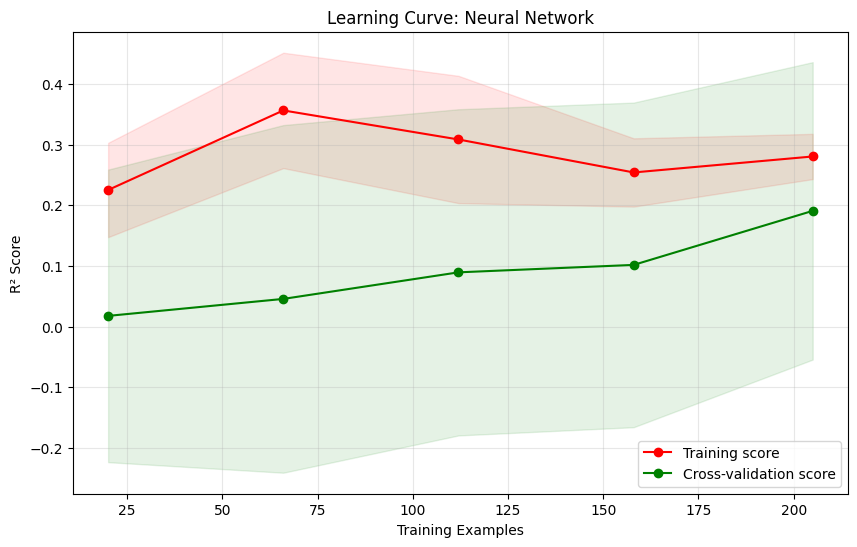

In [51]:
# Plot learning curve
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.xlabel('Training Examples')
plt.ylabel('R² Score')
plt.title(f'Learning Curve: Neural Network')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

In [52]:
# Plot hyperparameter efficiency for hidden layers
hidden_sizes = ['(10,)', '(20,)', '(50,)', '(100,)', '(10,10)', '(20,10)']
hidden_scores = []
hidden_times = []

for h in hidden_layers:
    results = [r for r in nn_results if r['hidden'] == h and
               r['activation'] == best_nn['activation'] and r['alpha'] == best_nn['alpha']]
    if results:
        hidden_scores.append(results[0]['test_r2'])
        hidden_times.append(results[0]['train_time'])

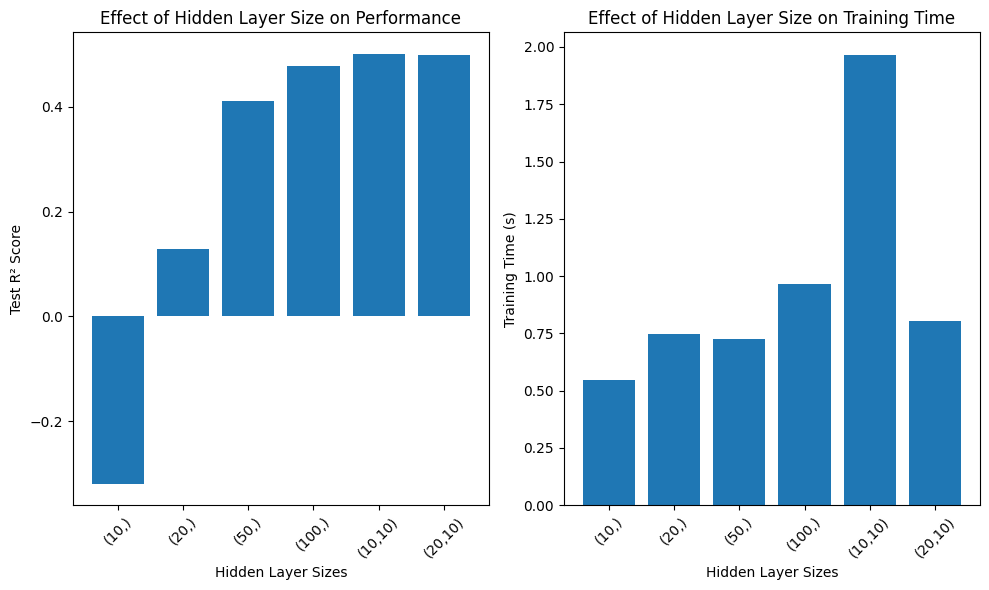

In [53]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.bar(hidden_sizes, hidden_scores)
plt.xlabel('Hidden Layer Sizes')
plt.ylabel('Test R² Score')
plt.title('Effect of Hidden Layer Size on Performance')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.bar(hidden_sizes, hidden_times)
plt.xlabel('Hidden Layer Sizes')
plt.ylabel('Training Time (s)')
plt.title('Effect of Hidden Layer Size on Training Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [54]:
# Curse of dimensionality for Neural Network
nn_dim_train_scores = []
nn_dim_test_scores = []

for dim in range(1, X_train_scaled.shape[1] + 1):
    # Use first dim features
    X_train_subset = X_train_scaled[:, :dim]
    X_test_subset = X_test_scaled[:, :dim]

    nn_dim = MLPRegressor(
        hidden_layer_sizes=best_nn['hidden'],
        activation=best_nn['activation'],
        alpha=best_nn['alpha'],
        max_iter=1000,
        random_state=42
    )
    nn_dim.fit(X_train_subset, y_train)

    nn_dim_train_scores.append(r2_score(y_train, nn_dim.predict(X_train_subset)))
    nn_dim_test_scores.append(r2_score(y_test, nn_dim.predict(X_test_subset)))

### **2. k-Nearest Neighbors**

In [56]:
# Define KNN hyperparameter options
n_neighbors_options = [3, 5, 7, 9, 11, 13, 15, 17, 19]
weights_options = ['uniform', 'distance']
metric_options = [1, 2]  # 1=Manhattan, 2=Euclidean

# Keep track of model performances
knn_results = []

# Grid search for KNN
for n_neighbors in n_neighbors_options:
    for weights in weights_options:
        for p in metric_options:
            knn = KNeighborsRegressor(
                n_neighbors=n_neighbors,
                weights=weights,
                p=p
            )

            # Time the training
            start_time = time.time()
            knn.fit(X_train_scaled, y_train)
            train_time = time.time() - start_time

            # Evaluate
            train_pred = knn.predict(X_train_scaled)
            test_pred = knn.predict(X_test_scaled)

            train_r2 = r2_score(y_train, train_pred)
            test_r2 = r2_score(y_test, test_pred)

            knn_results.append({
                'n_neighbors': n_neighbors,
                'weights': weights,
                'p': p,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'train_time': train_time
            })

# Find best model
best_knn = max(knn_results, key=lambda x: x['test_r2'])
print(f"Best KNN parameters: n_neighbors={best_knn['n_neighbors']}, weights={best_knn['weights']}, p={best_knn['p']}")
print(f"Best KNN test R²: {best_knn['test_r2']:.4f}")

Best KNN parameters: n_neighbors=19, weights=uniform, p=1
Best KNN test R²: 0.4977


In [57]:
# Train final model with best parameters
knn_model = KNeighborsRegressor(
    n_neighbors=best_knn['n_neighbors'],
    weights=best_knn['weights'],
    p=best_knn['p']
)
knn_model.fit(X_train_scaled, y_train)

KNeighborsRegressor(n_neighbors=19, p=1)

In [58]:
# Generate predictions
knn_train_pred = knn_model.predict(X_train_scaled)
knn_test_pred = knn_model.predict(X_test_scaled)

In [59]:
# Calculate metrics
knn_train_mse = mean_squared_error(y_train, knn_train_pred)
knn_train_r2 = r2_score(y_train, knn_train_pred)
knn_test_mse = mean_squared_error(y_test, knn_test_pred)
knn_test_r2 = r2_score(y_test, knn_test_pred)

print(f"KNN Training MSE: {knn_train_mse:.2f}")
print(f"KNN Training R²: {knn_train_r2:.4f}")
print(f"KNN Test MSE: {knn_test_mse:.2f}")
print(f"KNN Test R²: {knn_test_r2:.4f}")

KNN Training MSE: 77227.32
KNN Training R²: 0.5199
KNN Test MSE: 96591.49
KNN Test R²: 0.4977


In [61]:
# Create learning curve for KNN
train_sizes, train_scores, test_scores = learning_curve(
    knn_model, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='r2'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

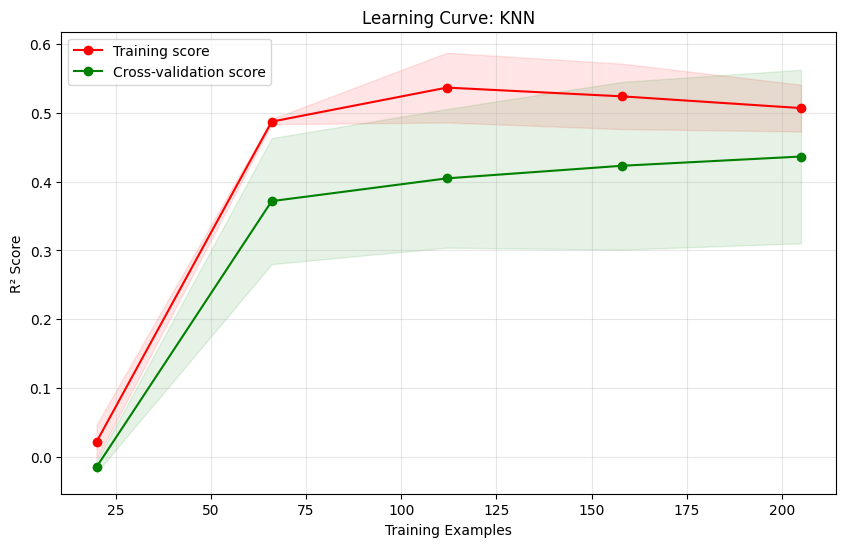

In [62]:
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.xlabel('Training Examples')
plt.ylabel('R² Score')
plt.title(f'Learning Curve: KNN')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

In [64]:
# Plot effect of n_neighbors on performance
n_neighbors_scores = []
n_neighbors_times = []

for n in n_neighbors_options:
    results = [r for r in knn_results if r['n_neighbors'] == n and
               r['weights'] == best_knn.weights and r['p'] == best_knn.p] # Access attributes directly
    if results:
        n_neighbors_scores.append(results[0]['test_r2'])
        n_neighbors_times.append(results[0]['train_time'])

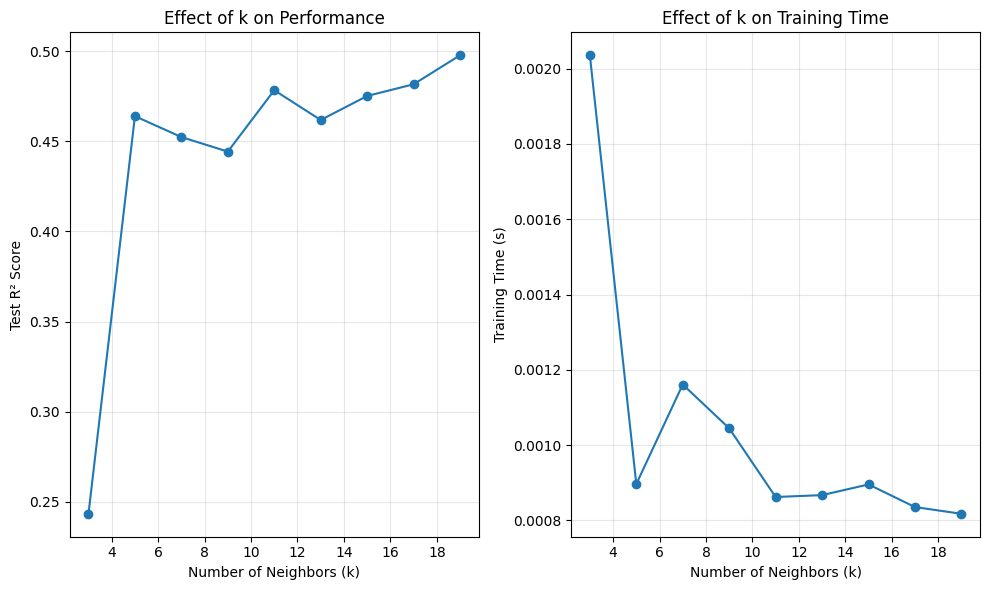

In [65]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.plot(n_neighbors_options, n_neighbors_scores, 'o-')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Test R² Score')
plt.title('Effect of k on Performance')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(n_neighbors_options, n_neighbors_times, 'o-')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Training Time (s)')
plt.title('Effect of k on Training Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [67]:
# Curse of dimensionality for KNN
knn_dim_train_scores = []
knn_dim_test_scores = []

for dim in range(1, X_train_scaled.shape[1] + 1):
    # Use first dim features
    X_train_subset = X_train_scaled[:, :dim]
    X_test_subset = X_test_scaled[:, :dim]

    knn_dim = KNeighborsRegressor(
        n_neighbors=n_neighbors, # Use the variable 'n_neighbors'
        weights=weights,           # Use the variable 'weights'
        p=p                       # Use the variable 'p'
    )
    knn_dim.fit(X_train_subset, y_train)

    knn_dim_train_scores.append(r2_score(y_train, knn_dim.predict(X_train_subset)))
    knn_dim_test_scores.append(r2_score(y_test, knn_dim.predict(X_test_subset)))

### **3. Kernel Ridge Regression**

In [68]:
# Define Kernel Ridge hyperparameter options
alpha_options = [0.001, 0.01, 0.1, 1.0, 10.0]
kernel_options = ['linear', 'rbf', 'poly']
gamma_options = [0.001, 0.01, 0.1, 1.0]

# Keep track of model performances
kr_results = []

# Grid search for Kernel Ridge Regression
for alpha in alpha_options:
    for kernel in kernel_options:
        for gamma in gamma_options:
            kr = KernelRidge(
                alpha=alpha,
                kernel=kernel,
                gamma=gamma
            )

            # Time the training
            start_time = time.time()
            kr.fit(X_train_scaled, y_train)
            train_time = time.time() - start_time

            # Evaluate
            train_pred = kr.predict(X_train_scaled)
            test_pred = kr.predict(X_test_scaled)

            train_r2 = r2_score(y_train, train_pred)
            test_r2 = r2_score(y_test, test_pred)

            kr_results.append({
                'alpha': alpha,
                'kernel': kernel,
                'gamma': gamma,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'train_time': train_time
            })

# Find best model
best_kr = max(kr_results, key=lambda x: x['test_r2'])
print(f"Best Kernel Ridge parameters: alpha={best_kr['alpha']}, kernel={best_kr['kernel']}, gamma={best_kr['gamma']}")
print(f"Best Kernel Ridge test R²: {best_kr['test_r2']:.4f}")

Best Kernel Ridge parameters: alpha=1.0, kernel=poly, gamma=0.01
Best Kernel Ridge test R²: 0.5507


In [69]:
# Train final model with best parameters
kr_model = KernelRidge(
    alpha=best_kr['alpha'],
    kernel=best_kr['kernel'],
    gamma=best_kr['gamma']
)
kr_model.fit(X_train_scaled, y_train)

KernelRidge(alpha=1.0, gamma=0.01, kernel='poly')

In [70]:
# Generate predictions
kr_train_pred = kr_model.predict(X_train_scaled)
kr_test_pred = kr_model.predict(X_test_scaled)

In [71]:
# Calculate metrics
kr_train_mse = mean_squared_error(y_train, kr_train_pred)
kr_train_r2 = r2_score(y_train, kr_train_pred)
kr_test_mse = mean_squared_error(y_test, kr_test_pred)
kr_test_r2 = r2_score(y_test, kr_test_pred)

print(f"Kernel Ridge Training MSE: {kr_train_mse:.2f}")
print(f"Kernel Ridge Training R²: {kr_train_r2:.4f}")
print(f"Kernel Ridge Test MSE: {kr_test_mse:.2f}")
print(f"Kernel Ridge Test R²: {kr_test_r2:.4f}")

Kernel Ridge Training MSE: 68613.39
Kernel Ridge Training R²: 0.5735
Kernel Ridge Test MSE: 86396.72
Kernel Ridge Test R²: 0.5507


In [72]:
# Calculate metrics
kr_train_mse = mean_squared_error(y_train, kr_train_pred)
kr_train_r2 = r2_score(y_train, kr_train_pred)
kr_test_mse = mean_squared_error(y_test, kr_test_pred)
kr_test_r2 = r2_score(y_test, kr_test_pred)

print(f"Kernel Ridge Training MSE: {kr_train_mse:.2f}")
print(f"Kernel Ridge Training R²: {kr_train_r2:.4f}")
print(f"Kernel Ridge Test MSE: {kr_test_mse:.2f}")
print(f"Kernel Ridge Test R²: {kr_test_r2:.4f}")

Kernel Ridge Training MSE: 68613.39
Kernel Ridge Training R²: 0.5735
Kernel Ridge Test MSE: 86396.72
Kernel Ridge Test R²: 0.5507


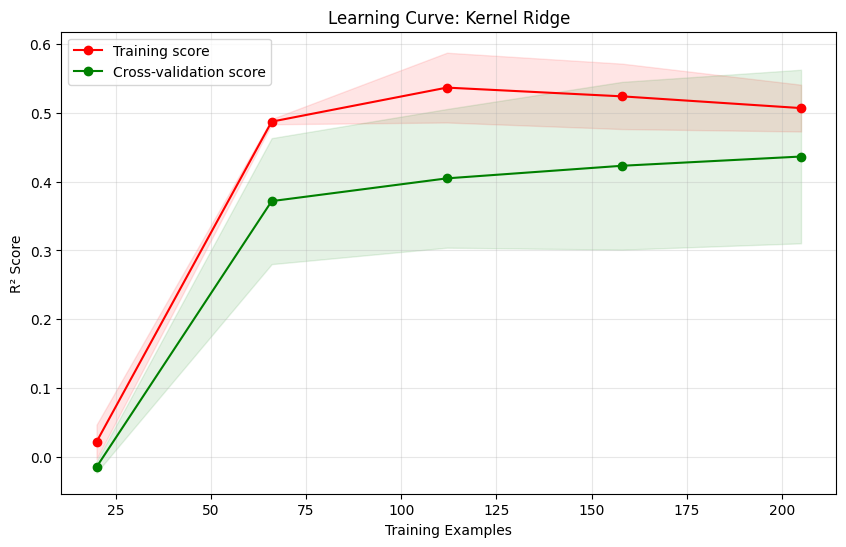

In [73]:
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.xlabel('Training Examples')
plt.ylabel('R² Score')
plt.title(f'Learning Curve: Kernel Ridge')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

In [74]:
# Plot effect of alpha on performance
alpha_scores = []
alpha_times = []

for a in alpha_options:
    results = [r for r in kr_results if r['alpha'] == a and
               r['kernel'] == best_kr['kernel'] and r['gamma'] == best_kr['gamma']]
    if results:
        alpha_scores.append(results[0]['test_r2'])
        alpha_times.append(results[0]['train_time'])

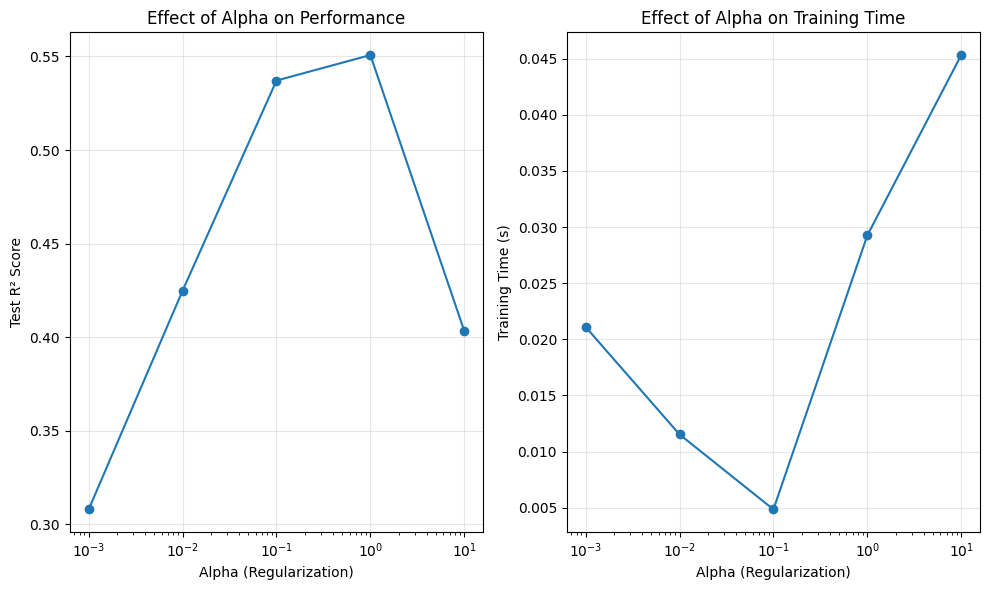

In [75]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.semilogx(alpha_options, alpha_scores, 'o-')
plt.xlabel('Alpha (Regularization)')
plt.ylabel('Test R² Score')
plt.title('Effect of Alpha on Performance')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.semilogx(alpha_options, alpha_times, 'o-')
plt.xlabel('Alpha (Regularization)')
plt.ylabel('Training Time (s)')
plt.title('Effect of Alpha on Training Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [76]:
# Curse of dimensionality for Kernel Ridge
kr_dim_train_scores = []
kr_dim_test_scores = []

for dim in range(1, X_train_scaled.shape[1] + 1):
    # Use first dim features
    X_train_subset = X_train_scaled[:, :dim]
    X_test_subset = X_test_scaled[:, :dim]

    kr_dim = KernelRidge(
        alpha=best_kr['alpha'],
        kernel=best_kr['kernel'],
        gamma=best_kr['gamma']
    )
    kr_dim.fit(X_train_subset, y_train)

    kr_dim_train_scores.append(r2_score(y_train, kr_dim.predict(X_train_subset)))
    kr_dim_test_scores.append(r2_score(y_test, kr_dim.predict(X_test_subset)))

### **4. Support Vector Machines**

In [77]:
# Define SVR hyperparameter options - limited to save time
C_options = [0.1, 1.0, 10.0]
kernel_options = ['linear', 'rbf']
gamma_options = ['scale', 0.1]
epsilon_options = [0.1]

# Keep track of model performances
svr_results = []

# Grid search for SVR
for C in C_options:
    for kernel in kernel_options:
        for gamma in gamma_options:
            for epsilon in epsilon_options:
                svr = SVR(
                    C=C,
                    kernel=kernel,
                    gamma=gamma,
                    epsilon=epsilon
                )

                # Time the training
                start_time = time.time()
                svr.fit(X_train_scaled, y_train)
                train_time = time.time() - start_time

                # Evaluate
                train_pred = svr.predict(X_train_scaled)
                test_pred = svr.predict(X_test_scaled)

                train_r2 = r2_score(y_train, train_pred)
                test_r2 = r2_score(y_test, test_pred)

                svr_results.append({
                    'C': C,
                    'kernel': kernel,
                    'gamma': gamma,
                    'epsilon': epsilon,
                    'train_r2': train_r2,
                    'test_r2': test_r2,
                    'train_time': train_time
                })

# Find best model
best_svr = max(svr_results, key=lambda x: x['test_r2'])
print(f"Best SVR parameters: C={best_svr['C']}, kernel={best_svr['kernel']}, gamma={best_svr['gamma']}, epsilon={best_svr['epsilon']}")
print(f"Best SVR test R²: {best_svr['test_r2']:.4f}")

Best SVR parameters: C=1.0, kernel=linear, gamma=scale, epsilon=0.1
Best SVR test R²: 0.3058


In [78]:
# Train final model with best parameters
svr_model = SVR(
    C=best_svr['C'],
    kernel=best_svr['kernel'],
    gamma=best_svr['gamma'],
    epsilon=best_svr['epsilon']
)
svr_model.fit(X_train_scaled, y_train)

SVR(kernel='linear')

In [79]:
# Generate predictions
svr_train_pred = svr_model.predict(X_train_scaled)
svr_test_pred = svr_model.predict(X_test_scaled)

In [80]:
# Calculate metrics
svr_train_mse = mean_squared_error(y_train, svr_train_pred)
svr_train_r2 = r2_score(y_train, svr_train_pred)
svr_test_mse = mean_squared_error(y_test, svr_test_pred)
svr_test_r2 = r2_score(y_test, svr_test_pred)

print(f"SVR Training MSE: {svr_train_mse:.2f}")
print(f"SVR Training R²: {svr_train_r2:.4f}")
print(f"SVR Test MSE: {svr_test_mse:.2f}")
print(f"SVR Test R²: {svr_test_r2:.4f}")

SVR Training MSE: 111350.89
SVR Training R²: 0.3078
SVR Test MSE: 133501.68
SVR Test R²: 0.3058


In [81]:
# Create learning curve for SVR
train_sizes, train_scores, test_scores = learning_curve(
    svr_model, X_train_scaled, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5), scoring='r2'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

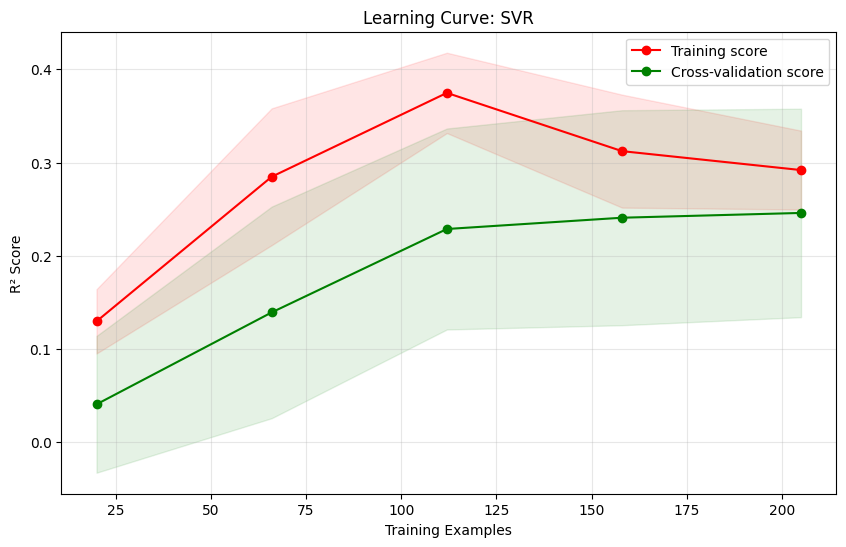

In [82]:
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')
plt.xlabel('Training Examples')
plt.ylabel('R² Score')
plt.title(f'Learning Curve: SVR')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

In [83]:
# Plot effect of C on performance
C_scores = []
C_times = []

for c in C_options:
    results = [r for r in svr_results if r['C'] == c and
               r['kernel'] == best_svr['kernel'] and r['gamma'] == best_svr['gamma']
               and r['epsilon'] == best_svr['epsilon']]
    if results:
        C_scores.append(results[0]['test_r2'])
        C_times.append(results[0]['train_time'])

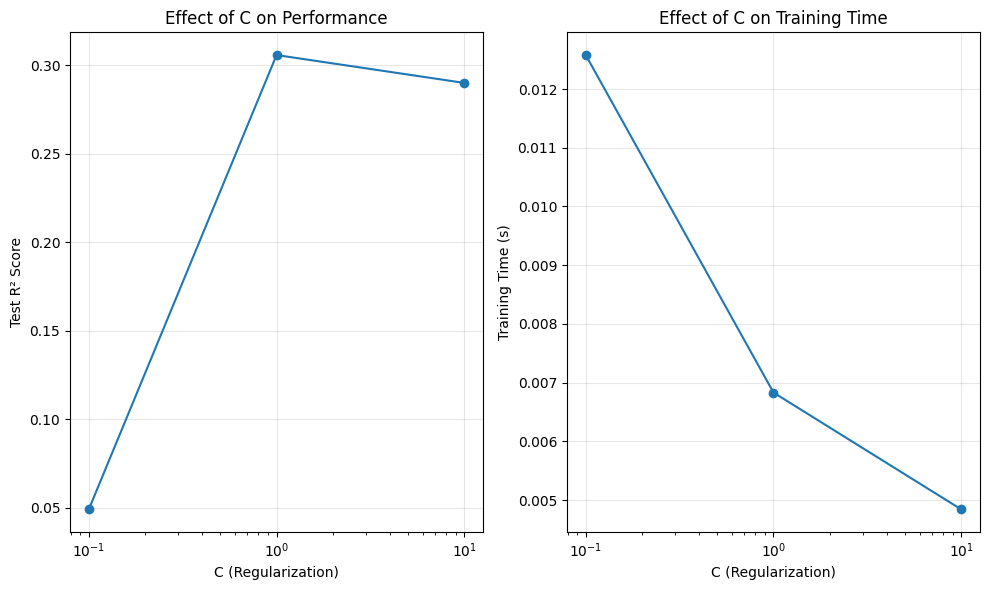

In [84]:
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.semilogx(C_options, C_scores, 'o-')
plt.xlabel('C (Regularization)')
plt.ylabel('Test R² Score')
plt.title('Effect of C on Performance')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.semilogx(C_options, C_times, 'o-')
plt.xlabel('C (Regularization)')
plt.ylabel('Training Time (s)')
plt.title('Effect of C on Training Time')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [85]:
# Curse of dimensionality for SVR
svr_dim_train_scores = []
svr_dim_test_scores = []

for dim in range(1, X_train_scaled.shape[1] + 1):
    # Use first dim features
    X_train_subset = X_train_scaled[:, :dim]
    X_test_subset = X_test_scaled[:, :dim]

    svr_dim = SVR(
        C=best_svr['C'],
        kernel=best_svr['kernel'],
        gamma=best_svr['gamma'],
        epsilon=best_svr['epsilon']
    )
    svr_dim.fit(X_train_subset, y_train)

    svr_dim_train_scores.append(r2_score(y_train, svr_dim.predict(X_train_subset)))
    svr_dim_test_scores.append(r2_score(y_test, svr_dim.predict(X_test_subset)))